In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from scipy.interpolate import lagrange

def cheby_pts(x,p):
    # Code from Lecture 04 Lagrange Interpolation notebook
    for i in range(0,p+1):
        x[i]=np.cos((2*i+1)/(2*p+2)*np.pi)
    x[0]=-1
    x[p]=1
    return x

# Function from Lecture 04 Lagrange Interpolation notebook
def robust_lagrange(x, f):
    x = np.array(x)
    @np.vectorize
    def interp(xn):
        dn = xn - x
        r = 0
        for i in range(len(x)):
            d = x[i] - x
            L =   np.product(dn[0:i] / d[0:i]) \
                * np.product(dn[i+1:] / d[i+1:])
            r = r + L * f[i]
        return r
    return interp


# Functions of interest:
def f1(x):
    return 1 / (1+25*x**2)

def f2(x):
    return np.abs(x)

def f3(x):
    return np.heaviside(x-0.25, 0)


# Error evaluations:
def L2_norm(fapprox, fexact, N):
    arg = np.sum( (fapprox - fexact)**2 )
    return np.sqrt(arg / N)

def max_norm(fapprox, fexact):
    return np.max(abs(fapprox - fexact))

high_res = 1024
x_high = np.linspace(-1,1,high_res+1)
f1_exact = f1(x_high)
f2_exact = f2(x_high)
f3_exact = f3(x_high)

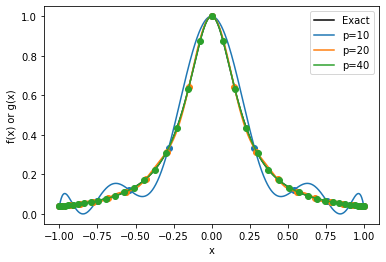

In [2]:
plt.figure()
plt.plot(x_high, f1_exact, 'k', label='Exact')

ps = [10,20,40]
colors = ["tab:blue", "tab:orange", "tab:green"]

for i in range(len(ps)):
    p = ps[i]
    color = colors[i]
    x_reg = np.linspace(-1,1,p+1)
    x_cheby = cheby_pts(x_reg, p)
    f1_reg = f1(x_reg)
    f1_int = robust_lagrange(x_cheby, f1_reg)

    plt.plot(x_high, f1_int(x_high), label=f'p={p}', color=color)
    plt.plot(x_cheby, f1_int(x_cheby), 'o', color=color)
    plt.plot()

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x) or g(x)')
plt.show()

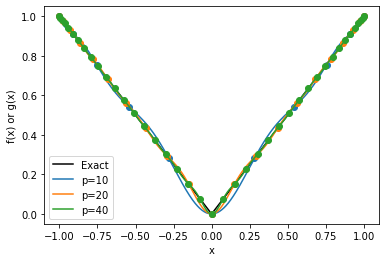

In [3]:
plt.figure()
plt.plot(x_high, f2_exact, 'k', label='Exact')

ps = [10,20,40]
colors = ["tab:blue", "tab:orange", "tab:green"]

for i in range(len(ps)):
    p = ps[i]
    color = colors[i]
    x_reg = np.linspace(-1,1,p+1)
    x_cheby = cheby_pts(x_reg, p)
    f2_reg = f2(x_reg)
    f2_int = robust_lagrange(x_cheby, f2_reg)

    plt.plot(x_high, f2_int(x_high), label=f'p={p}', color=color)
    plt.plot(x_cheby, f2_int(x_cheby), 'o', color=color)
    plt.plot()

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x) or g(x)')
plt.show()

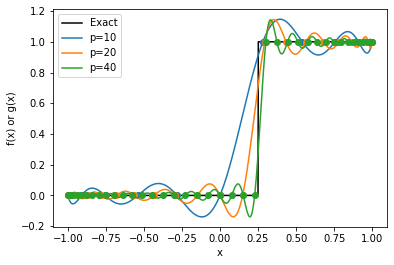

In [4]:
plt.figure()
plt.plot(x_high, f3_exact, 'k', label='Exact')

ps = [10,20,40]
colors = ["tab:blue", "tab:orange", "tab:green"]

for i in range(len(ps)):
    p = ps[i]
    color = colors[i]
    x_reg = np.linspace(-1,1,p+1)
    x_cheby = cheby_pts(x_reg, p)
    f3_reg = f3(x_reg)
    f3_int = robust_lagrange(x_cheby, f3_reg)

    plt.plot(x_high, f3_int(x_high), label=f'p={p}', color=color)
    plt.plot(x_cheby, f3_int(x_cheby), 'o', color=color)
    plt.plot()

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x) or g(x)')
plt.show()

In [5]:
ps = [2**i for i in range(9)]
N = len(x_high)

L2errs_f1 = np.zeros((len(ps),1))
L2errs_f2 = np.zeros((len(ps),1))
L2errs_f3 = np.zeros((len(ps),1))

maxerrs_f1 = np.zeros((len(ps),1))
maxerrs_f2 = np.zeros((len(ps),1))
maxerrs_f3 = np.zeros((len(ps),1))

for i in range(len(ps)):
    p = ps[i]
    x_reg = np.linspace(-1,1,p+1)
    x_cheby = cheby_pts(x_reg, p)
    
    f1_reg = f1(x_reg)
    f1_int = robust_lagrange(x_cheby, f1_reg)
    f1_int_eval = f1_int(x_high)
    L2errs_f1[i] = L2_norm(f1_int_eval, f1_exact, N)
    maxerrs_f1[i] = max_norm(f1_int_eval, f1_exact)
    
    f2_reg = f2(x_reg)
    f2_int = robust_lagrange(x_cheby, f2_reg)
    f2_int_eval = f2_int(x_high)
    L2errs_f2[i] = L2_norm(f2_int_eval, f2_exact, N)
    maxerrs_f2[i] = max_norm(f2_int_eval, f2_exact)
    
    f3_reg = f3(x_reg)
    f3_int = robust_lagrange(x_cheby, f3_reg)
    f3_int_eval = f3_int(x_high)
    L2errs_f3[i] = L2_norm(f3_int_eval, f3_exact, N)
    maxerrs_f3[i] = max_norm(f3_int_eval, f3_exact)
    
print('Done.')

Done.


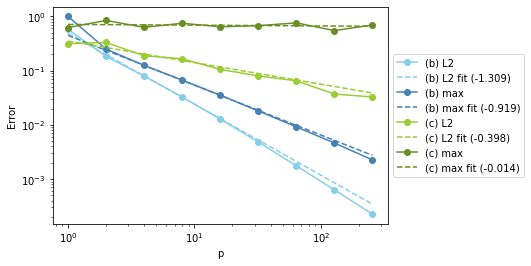

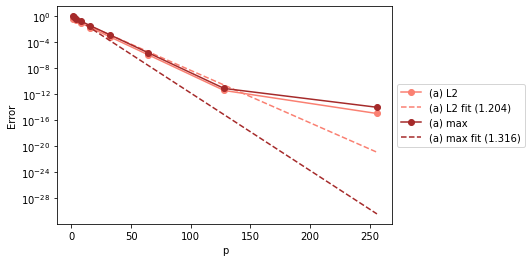

In [55]:
a_L2 = "salmon"
a_max = "brown"
b_L2 = "skyblue"
b_max = "steelblue"
c_L2 = "yellowgreen"
c_max = "olivedrab"

from scipy.optimize import curve_fit

def model(x, A, B):
    return A * x**B

def model_a(x,A,B):
    return A* B**-x

ps = np.array(ps)

params_aL2, _ = curve_fit(model_a, ps[:], L2errs_f1[:].ravel())
A_aL2, B_aL2 = params_aL2
params_amax, _ = curve_fit(model_a, ps, maxerrs_f1.ravel())
A_amax, B_amax = params_amax

params_bL2, _ = curve_fit(model, ps[2:], L2errs_f2[2:].ravel())
A_bL2, B_bL2 = params_bL2
params_bmax, _ = curve_fit(model, ps[2:], maxerrs_f2[2:].ravel())
A_bmax, B_bmax = params_bmax

params_cL2, _ = curve_fit(model, ps, L2errs_f3.ravel())
A_cL2, B_cL2 = params_cL2
params_cmax, _ = curve_fit(model, ps, maxerrs_f3.ravel())
A_cmax, B_cmax = params_cmax


fig,ax = plt.subplots()

plt.loglog(ps,L2errs_f2, '-o', color=b_L2, label='(b) L2')
plt.loglog(ps,A_bL2*ps**B_bL2, '--', color=b_L2, label=f'(b) L2 fit ({np.round(B_bL2,3)})')
plt.loglog(ps,maxerrs_f2, '-o', color=b_max, label='(b) max')
plt.loglog(ps,A_bmax*ps**B_bmax, '--', color=b_max, label=f'(b) max fit ({np.round(B_bmax,3)})')

plt.loglog(ps,L2errs_f3, '-o', color=c_L2, label='(c) L2')
plt.loglog(ps,A_cL2*ps**B_cL2, '--', color=c_L2, label=f'(c) L2 fit ({np.round(B_cL2,3)})')
plt.loglog(ps,maxerrs_f3, '-o', color=c_max, label='(c) max')
plt.loglog(ps,A_cmax*ps**B_cmax, '--', color=c_max, label=f'(c) max fit ({np.round(B_cmax,3)})')

plt.xlabel('p')
plt.ylabel('Error')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


fig2, ax2 = plt.subplots()

plt.semilogy(ps,L2errs_f1, '-o', color=a_L2, label='(a) L2')
plt.semilogy(ps,A_aL2*B_aL2**(-ps), '--', color=a_L2, label=f'(a) L2 fit ({np.round(B_aL2,3)})')
plt.semilogy(ps,maxerrs_f1, '-o', color=a_max, label='(a) max')
plt.semilogy(ps,A_amax*(B_amax**-ps), '--', color=a_max, label=f'(a) max fit ({np.round(B_amax,3)})')

plt.xlabel('p')
plt.ylabel('Error')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()